Размер датасета: (3000, 17)


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1



--- Информация о датасете ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  reg

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000



--- Распределение целевой переменной (default) ---
default
0    0.589667
1    0.410333
Name: proportion, dtype: float64
Размер признакового массива: (3000, 15)
Размер целевой переменной: (3000,)
Размер обучающей выборки: (2250, 15), (2250,)
Размер тестовой выборки: (750, 15), (750,)
Базовая точность: 0.5893
Базовая ROC-AUC:  0.5000
Лучшие параметры: {'logreg__C': 1}
Лучший ROC-AUC на кросс-валидации: 0.8632
Точность логистической регрессии: 0.7933
ROC-AUC логистической регрессии: 0.8647
График сохранен в папку figures/
График сохранен в папку figures/


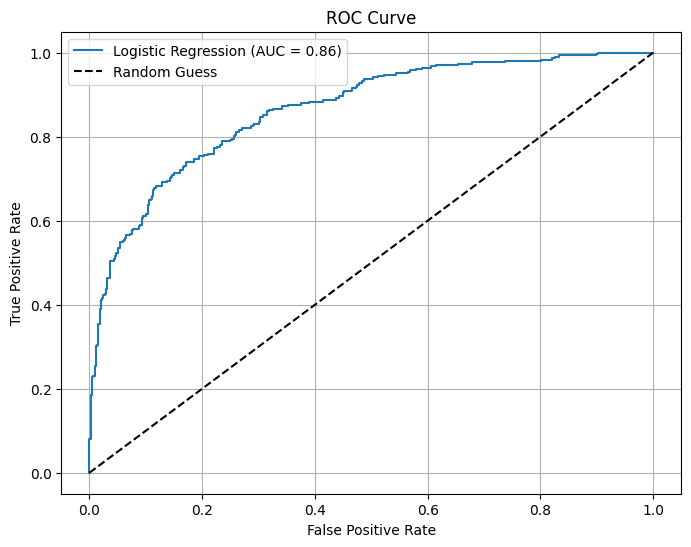

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report


%matplotlib inline


df = pd.read_csv('S05-hw-dataset.csv')

print(f"Размер датасета: {df.shape}")

display(df.head()) 

print("\n--- Информация о датасете ---")
df.info()
display(df.describe())


print("\n--- Распределение целевой переменной (default) ---")
print(df['default'].value_counts(normalize=True))

#  2. ПОДГОТОВКА ДАННЫХ 
X = df.drop(columns=['default', 'client_id'])
y = df['default']

print(f"Размер признакового массива: {X.shape}")
print(f"Размер целевой переменной: {y.shape}")

#  3. РАЗДЕЛЕНИЕ НА TRAIN И TEST 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}, {y_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}, {y_test.shape}")


#  4. БЕЙЗЛАЙН 
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
roc_dummy = roc_auc_score(y_test, y_prob_dummy)

print(f"Базовая точность: {acc_dummy:.4f}")
print(f"Базовая ROC-AUC:  {roc_dummy:.4f}")

#  5. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ 
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42))
])

# Параметры для перебора
params = {
    'logreg__C': [0.01, 0.1, 1, 10, 100]
}

# Поиск лучших параметров
grid = GridSearchCV(pipe, params, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid.best_score_:.4f}")

#  6. ФИНАЛЬНАЯ ПРОВЕРКА И ГРАФИК 
best_model = grid.best_estimator_


y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc_logreg = accuracy_score(y_test, y_pred)
roc_logreg = roc_auc_score(y_test, y_prob)

print(f"Точность логистической регрессии: {acc_logreg:.4f}")
print(f"ROC-AUC логистической регрессии: {roc_logreg:.4f}")

# Рисуем график ROC-кривой
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_logreg:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()

os.makedirs('figures', exist_ok=True)
# Сохраняем картинку
plt.savefig('figures/roc_curve.png')
print("График сохранен в папку figures/")



plt.show()

## 7. Выводы по эксперименту

### 1. Сравнение с бейзлайном
Мы построили простую точку отсчета с помощью `DummyClassifier` (стратегия `most_frequent`).
*   **Бейзлайн:**
    *   Accuracy: `0.5893` (просто доля мажоритарного класса).
    *   ROC-AUC: `0.5000` (соответствует случайному гаданию).
*   **Логистическая регрессия:**
    *   Accuracy: **`0.7933`** (прирост **+20.4%**).
    *   ROC-AUC: **`0.8647`** (прирост **+0.36**).

**Вывод:** Модель значительно превосходит случайное угадывание. Высокий ROC-AUC (~0.86) говорит о том, что линейная модель успешно нашла закономерности в данных и может уверенно ранжировать клиентов по вероятности дефолта.

### 2. Подбор гиперпараметров и стабильность
*   С помощью `GridSearchCV` был найден оптимальный коэффициент регуляризации **`C = 1`**. Это значение обеспечивает баланс, не допуская ни переобучения, ни недообучения.
*   Метрики на кросс-валидации (`0.8632`) и на отложенной тестовой выборке (`0.8647`) практически совпадают. Это подтверждает, что модель **стабильна** и мы провели **честный эксперимент** (без утечек данных и подгонки под тест).

### 3. Итог
Использование линейной модели (`LogisticRegression`) в связке с нормализацией признаков (`StandardScaler`) оказалось эффективным подходом для данной задачи кредитного скоринга. Мы получили интерпретируемую и достаточно точную модель, готовую к дальнейшему улучшению или внедрению.
